[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FranQuant/llm-regime-allocator/blob/main/notebooks/nb04_cross_family.ipynb)

In [1]:
# Colab setup: fetch the repo (data, results and the replayable LLM cache), work from its notebooks/ folder.
# Runs only on Colab; locally this cell does nothing. No API keys or paid calls are needed.
import os, subprocess, sys
if 'google.colab' in sys.modules and not os.path.exists('../src/lra'):
    repo = '/content/llm-regime-allocator'
    if not os.path.exists(repo):
        subprocess.run(['git', 'clone', '-q', '--depth', '1',
                        'https://github.com/FranQuant/llm-regime-allocator.git', repo], check=True)
    os.chdir(f'{repo}/notebooks')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pydantic>=2', 'scikit-learn'], check=True)

# nb04 — Does the result replicate across model families?

**Question.** nb02 and nb03 rest on one model. Is the blinded-snapshot result a property of LLMs or of Claude Sonnet 5.5? nb04 repeats it with three more families, each at the provider's default reasoning setting, with the same prompts and the same 222 months (217 scored), under a test registered before any paid call. Everything is read from `python scripts/score_phase8.py`; no API calls.

## Setup

| Model | Provider | Knowledge cutoff (provider docs) |
|---|---|---|
| Claude Sonnet 5.5 (reference, from nb02) | Anthropic | Jun 2026 |
| GPT-6.1-sol | OpenAI | Apr 2026 |
| Gemini 3.8 Flash | Google | Mar 2026 |
| GLM-5.3 (open weights, via Ollama Cloud) | Zhipu | not published |

**Pre-registered test** (`configs/phase8.toml`, committed before the first paid call). A model *replicates* if, on the 217 labelled months, (i) its Brier score, $\frac1N\sum_t\sum_k(p_{t,k}-y_{t,k})^2$, is below uniform (0.750), (ii) the block-bootstrap 95% CI of the gap excludes zero, and (iii) it beats the best walk-forward ML model on the same blinded inputs (0.871).

**Contamination probe.** The date-recovery probe of nb02 on the blinded snapshot; a month is *datable* for a model if its guess is within 12 months of the truth.

**Agreement.** The distance between two models' answers is the total-variation distance, $\mathrm{TV}(p,q)=\tfrac12\sum_k|p_k-q_k|$, averaged over months.

In [2]:
import sys
sys.path.insert(0, '../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
P8, L = Path('../results/phase8'), Path('../results/llm')
C = {'claude_sonnet': '#2a78d6', 'gpt_sol': '#eb6834', 'gemini_flash': '#1baf7a', 'glm': '#eda100'}
NAME = {'claude_sonnet': 'Sonnet 5.5', 'gpt_sol': 'GPT-6.1-sol', 'gemini_flash': 'Gemini 3.8 Flash',
        'glm': 'GLM-5.3', 'ensemble_4': 'average of 4', 'ensemble_3_new': 'average of 3 new'}
INK, MUTED = '#0b0b0b', '#52514e'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2,
                     'axes.edgecolor': MUTED, 'text.color': INK})

def fmt(df, pct=(), d0=(), d1=(), d2=()):
    """Display only: Sharpe 2 decimals, Brier 3, percentages 0 (stored results are untouched)."""
    f = {**{c: '{:.0%}' for c in pct}, **{c: '{:.0f}' for c in d0}, **{c: '{:.1f}' for c in d1}, **{c: '{:.2f}' for c in d2}}
    return df.style.format(f, precision=3, na_rep='–')
rd = lambda f: pd.read_csv(P8 / f)

## 1. The pre-registered test

In [3]:
pr = rd('primary.csv').set_index('model').rename(index=NAME)
fmt(pr[['brier', 'minus_uniform', 'ci_lo', 'ci_hi', 'hit_rate', 'brier_first_release', 'replicates']], pct=['hit_rate'])

,brier,minus_uniform,ci_lo,ci_hi,hit_rate,brier_first_release,replicates
model,,,,,,,
Sonnet 5.5,0.668,-0.082,-0.140,-0.028,46%,0.646,True
GPT-6.1-sol,0.689,-0.061,-0.122,-0.001,40%,0.665,True
Gemini 3.8 Flash,0.724,-0.026,-0.101,0.052,46%,0.687,False
GLM-5.3,0.719,-0.031,-0.089,0.025,39%,0.689,False
average of 4,0.688,-0.062,-0.124,-0.001,43%,0.659,True
average of 3 new,0.700,-0.050,-0.114,0.015,41%,0.669,False


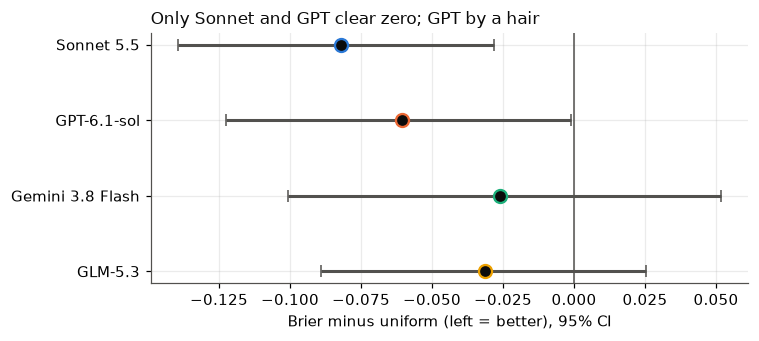

In [4]:
m = pr.loc[[NAME[k] for k in C]]
fig, ax = plt.subplots(figsize=(7, 3.2))
y = np.arange(len(m))[::-1]
ax.errorbar(m.minus_uniform, y, xerr=[m.minus_uniform - m.ci_lo, m.ci_hi - m.minus_uniform], fmt='o',
            color=INK, ecolor=MUTED, capsize=4)
for yi, k in zip(y, C):
    ax.plot(m.loc[NAME[k], 'minus_uniform'], yi, 'o', color=C[k], ms=9)
ax.axvline(0, color=MUTED, lw=1)
ax.set_yticks(y, m.index); ax.set_xlabel('Brier minus uniform (left = better), 95% CI')
ax.set_title('Only Sonnet and GPT clear zero; GPT by a hair', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

**Reading.** **Key finding:** all four LLMs beat uniform on Brier (0.668–0.724 against 0.750) and all four beat ML on identical inputs (against 0.871), so that part replicates across families. Clearing uniform with confidence does not: Sonnet and GPT do (GPT's upper bound is −0.001), while Gemini's and GLM's intervals include zero. Labels from first data releases instead of today's vintage improve every model by about 0.02–0.04 and change no ranking.

## 2. Contamination: can each model date the blinded snapshot?

Blinding was designed on Sonnet (nb02); the question is whether it holds for the other models.

In [5]:
fmt(rd('probe.csv').set_index('model').rename(index=NAME)[['status', 'mae_months', 'exact_month', 'within_12m',
    'brier_gain_datable', 'brier_gain_undatable', 'n_datable', 'n_undatable']], pct=['exact_month', 'within_12m'], d0=['n_datable', 'n_undatable'], d1=['mae_months'])

,status,mae_months,exact_month,within_12m,brier_gain_datable,brier_gain_undatable,n_datable,n_undatable
model,,,,,,,,
Sonnet 5.5,complete,45.5,14%,50%,-0.114,-0.051,108,109
GPT-6.1-sol,complete,2.0,94%,98%,-0.059,-0.316,216,1
Gemini 3.8 Flash,complete,37.0,29%,60%,-0.045,0.004,134,83
GLM-5.3,not completed (reasoning exceeded the output cap),–,–,–,–,–,–,–


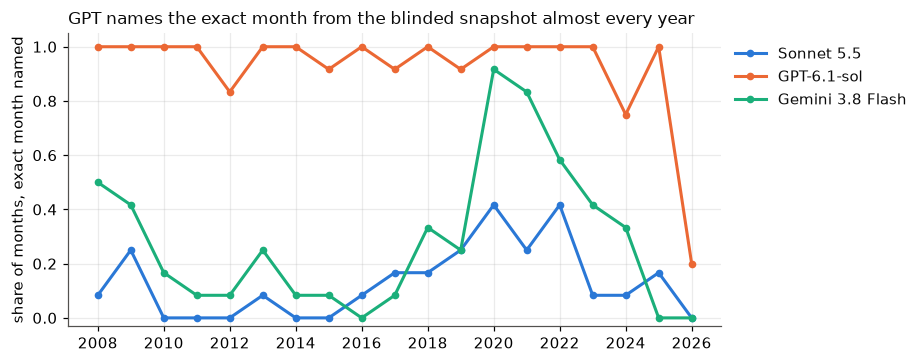

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 3.4))
for k in ('claude_sonnet', 'gpt_sol', 'gemini_flash'):
    e = pd.read_csv(L / k / 'date_probe_blinded_run0.csv', parse_dates=['date'], index_col='date')['error_months']
    e = e.loc['2008':]                       # 2007 has a single month
    s = (e.abs() == 0).groupby(e.index.year).mean()
    ax.plot(s.index, s.values, marker='o', ms=4, color=C[k], label=NAME[k])
ax.set_xticks(range(2008, 2027, 2))
ax.set_ylabel('share of months, exact month named'); ax.set_ylim(-0.03, 1.05)
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.0, 1.0))
ax.set_title('GPT names the exact month from the blinded snapshot almost every year', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

In [7]:
g = pd.read_csv(L / 'gpt_sol' / 'date_probe_blinded_run0.csv', parse_dates=['date'], index_col='date')
g.loc['2025-10':, ['guess_year', 'guess_month', 'error_months', 'confidence']]   # GPT near its Apr-2026 cutoff

,guess_year,guess_month,error_months,confidence
date,,,,
2025-10-31,2025.0,10.0,0.0,0.88
2025-11-28,2025.0,11.0,0.0,0.96
2025-12-31,2025.0,12.0,0.0,0.94
2026-01-30,2026.0,1.0,0.0,0.88
2026-02-27,2026.0,3.0,1.0,0.50
2026-03-31,2013.0,6.0,-153.0,0.35
2026-04-30,2020.0,11.0,-65.0,0.55
2026-05-29,2021.0,4.0,-61.0,0.76


**Reading.** **Key finding:** blinding is not model-proof. GPT-6.1-sol names the exact month in 94% of months from z-scores alone (Sonnet 14%, Gemini 29%) and is within 12 months in 216 of 217, citing episodes such as gold's 2013 collapse or Operation Twist. It is exact through January 2026 and breaks down from March 2026, around its April 2026 knowledge cutoff, where its training data thins out: the signature of memory, not of a general dating skill. Gemini dates the COVID years far better than the rest of the sample (figure). **Consequence:** GPT passes the pre-registered test, but its pass is not clean evidence. GLM's probe did not complete (section 6), so its contamination is unmeasured.

## 3. Stability: a second run on every 4th month

None of these models can be made deterministic (reasoning models at provider defaults), so run-to-run variance is measured instead.

In [8]:
fmt(rd('variance.csv').set_index('model').rename(index=NAME), pct=['same_top_regime'], d0=['n_months', 'n_scored'])

,n_months,n_scored,brier_run0,brier_run1,mean_abs_dp,same_top_regime
model,,,,,,
GPT-6.1-sol,56,54,0.681,0.663,0.021,95%
Gemini 3.8 Flash,56,54,0.732,0.721,0.025,96%
GLM-5.3,56,54,0.718,0.729,0.049,86%


**Reading.** Answers are stable: probabilities move by 2–5 points on average between runs and the top regime is the same in 86–96% of months (54 scored months each). Single-run results are not noise-dominated.

## 4. Do the models agree?

In [9]:
a = rd('agreement.csv'); a['pair'] = a.a.map(NAME) + ' – ' + a.b.map(NAME)
fmt(a.set_index('pair')[['mean_tv_distance', 'same_top_regime']], pct=['same_top_regime'])

,mean_tv_distance,same_top_regime
pair,,
Sonnet 5.5 – GPT-6.1-sol,0.121,74%
Sonnet 5.5 – Gemini 3.8 Flash,0.172,81%
Sonnet 5.5 – GLM-5.3,0.119,76%
GPT-6.1-sol – Gemini 3.8 Flash,0.119,86%
GPT-6.1-sol – GLM-5.3,0.129,72%
Gemini 3.8 Flash – GLM-5.3,0.162,76%


**Reading.** Different families make similar calls: the same top regime in 72–87% of months, mean TV distance 0.12–0.17. The equal-weight average of the four (section 1) scores 0.688, no better than Sonnet alone (0.668), which suggests that the models' errors overlap.

## 5. Portfolios (descriptive, not part of the test)

Same playbook and post-hoc BL machinery as nb03, net of 2.5 bps; Sharpe difference against the uniform-probability control with a 6-month block-bootstrap CI on monthly excess returns. The two `ml_gbt` rows per family differ by their inputs: blinded (playbook Sharpe 0.59) and raw (0.75).

In [10]:
pf = rd('portfolios.csv')
s = pf.strategy.str.replace('llm_', '')
# the two GBT rows per family differ only by their inputs; keep their labels apart
pf['strategy'] = (s.str.replace(r'ml_gbt_blinded$', 'ml_gbt (blinded inputs)', regex=True)
                   .str.replace(r'ml_gbt$', 'ml_gbt (raw inputs)', regex=True).str.replace('_blinded', ''))
fmt(pf.set_index('strategy'), pct=['max_drawdown'], d2=['sharpe', 'sharpe_diff_vs_uniform_monthly', 'ci_lo', 'ci_hi'])

,sharpe,max_drawdown,sharpe_diff_vs_uniform_monthly,ci_lo,ci_hi
strategy,,,,,
playbook__sonnet,0.76,-16%,0.14,-0.03,0.31
playbook__gpt_sol,0.71,-19%,0.09,-0.06,0.23
playbook__gemini_flash,0.72,-19%,0.10,-0.07,0.26
playbook__glm,0.73,-19%,0.11,-0.02,0.23
playbook__ensemble_4,0.73,-18%,0.12,-0.04,0.26
playbook__ml_gbt (blinded inputs),0.59,-27%,-0.00,-0.16,0.12
playbook__ml_gbt (raw inputs),0.75,-18%,0.14,-0.08,0.30
playbook__oracle,0.96,-14%,0.35,0.01,0.66
bl_playbook__sonnet,0.65,-24%,0.06,-0.03,0.14


**Reading.** **Key finding:** no LLM playbook is distinguishable from the uniform control; only the look-ahead oracle is. The four land at Sharpe 0.71–0.76 with drawdowns of −16% to −19% (control 0.61; 60/40 0.66, −32%).

## 6. Deviations and limits

All declared in `configs/phase8.toml`.

- **Provider errors** are retried with backoff and never scored; no fallback model was used.
- **GLM probe not completed.** GLM-5.3 kept reasoning past the 8,000-token cap on every probe call (the pilot covered the regime task only); a declared re-run at 32,000 tokens also truncated, so under the pre-registered rule its probe is reported as not completed. 220 calls were truncated (215 at 8k, 5 at 32k); 5 of the 8k records were overwritten in the archive (`results/llm_cache_truncated/`) by the 32k re-run, which reused their cache keys; 215 records are kept. GLM's regime calls are complete (one parse retry, no failed month).
- **One reasoning setting per model** (provider default) and one main run; variance is measured on 56 months.
- **Cutoffs.** Every documented cutoff is after 2026-03 (GLM's is not published), so no model has a clean backtest window.

## What we can and cannot claim

- **Replicates across families:** all four LLMs forecast the blinded snapshot better than ML on identical inputs (Brier 0.668–0.724 against 0.871).
- **Does not replicate cleanly:** beating uniform with confidence. Sonnet does; GPT does but is contaminated; Gemini and GLM do not.
- **Blinding is not model-proof.** GPT dates the blinded snapshot almost perfectly before its cutoff and not after, so a backtest of an LLM forecaster on pre-cutoff data should report a date-recovery probe per model. For GLM the probe is missing.
- **Open:** whether the edge over uniform is reading or remembering. No backtest can settle it for these models.

## Next

nb05 edits the blinded snapshots and asks whether each model's answer follows the figures or the month, GPT included.